# DPOY Model

In [1]:
# For data handling
import pandas as pd
import numpy as np

# To manage model loading and save paths
import os
import json
import joblib
from datetime import datetime

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier

In [2]:
# Creating a timestamp for saving model version number by date
timestamp = datetime.now().strftime("%Y_%m_%d")

# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/cleaned"
PROCESSED_PATH = "../../data/processed"
ML_PATH = "../../models/ml"
DL_PATH = "../../models/dl"
os.makedirs(ML_PATH, exist_ok=True)
os.makedirs(DL_PATH, exist_ok=True)

# Create a timestamped subdirectory inside DL and ML Path
versioned_dl_path = os.path.join(DL_PATH, f"dpoy_{timestamp}")
os.makedirs(versioned_dl_path, exist_ok=True)

versioned_ml_path = os.path.join(ML_PATH, f"dpoy_{timestamp}")
os.makedirs(versioned_ml_path, exist_ok=True)

In [3]:
# Loading the cleaned player data set
player_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

In [4]:
# Loading the dpoy data set
dpoy_df = pd.read_csv(f"{PROCESSED_PATH}/dpoy_eda_cleaned.csv")

In [5]:
# Removing unnamed column
dpoy_df.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
# Creating a dataframe to hold the Season column before merging 
selected_features = list(dpoy_df.drop(columns=["is_DPOY"]).columns)
reduced_with_season = player_df[selected_features + ["Season", "is_DPOY"]].dropna()

In [7]:
# Checking to see if indexes match before merging
dpoy_df.index.equals(reduced_with_season.index)

True

In [8]:
# Merging processed dataset with modified dataset to retain Season column
dpoy_df["Season"] = reduced_with_season["Season"]

In [9]:
dpoy_df.head(5)


,DWS,BLK,TRB,FTA,GS,2P,PF,MP,STL,TOV,is_DPOY,Season
0,5.0,1.0,7.6,10.2,82.0,8.1,2.1,39.5,1.4,3.3,0,2010
1,5.2,1.0,7.3,10.2,76.0,8.4,1.6,39.0,1.6,3.4,0,2010
2,2.4,0.4,6.6,8.9,69.0,9.1,3.3,38.2,1.3,3.0,0,2010
3,4.0,0.3,5.4,7.4,73.0,8.5,2.6,38.8,1.5,3.2,0,2010
4,4.6,1.1,4.8,9.1,77.0,8.4,2.4,36.3,1.8,3.3,0,2010


In [10]:
# Checking to make sure no null values remain
print(dpoy_df.isnull().sum())

DWS        0
BLK        0
TRB        0
FTA        0
GS         0
2P         0
PF         0
MP         0
STL        0
TOV        0
is_DPOY    0
Season     0
dtype: int64


In [11]:
# Assigning everything in one go to save memory and compute time
X = dpoy_df.drop(columns=["is_DPOY", "Season"])
y = dpoy_df["is_DPOY"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [14]:
# Model results
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1901   39]
 [   0    4]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1940
           1       0.09      1.00      0.17         4

    accuracy                           0.98      1944
   macro avg       0.55      0.99      0.58      1944
weighted avg       1.00      0.98      0.99      1944



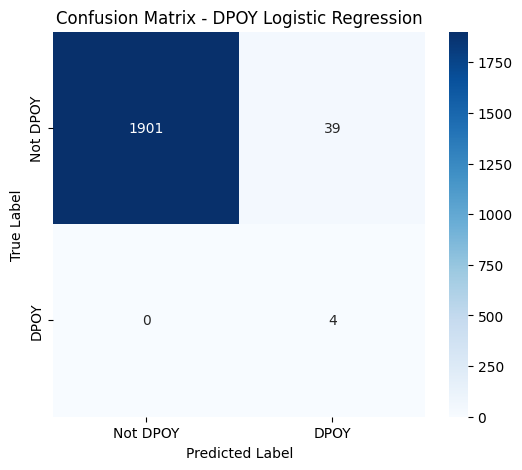

In [15]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not DPOY", "DPOY"],
            yticklabels=["Not DPOY", "DPOY"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DPOY Logistic Regression")
plt.show()

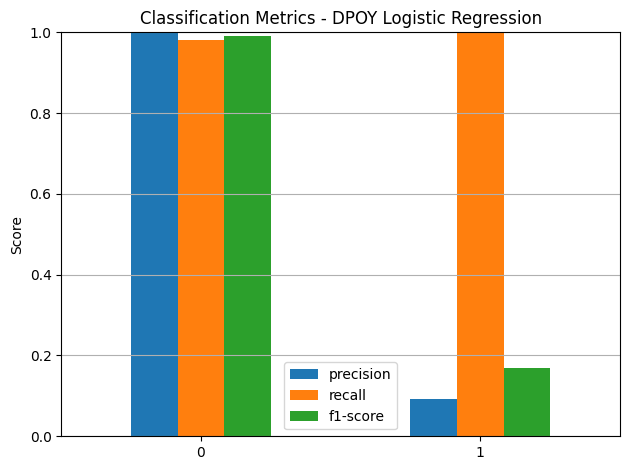

In [16]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Bar chart for precision, recall and f1-score
df_report.iloc[:2][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("Classification Metrics - DPOY Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

Using the balanced approach, the model correctly predicts the DPOY. But, it is not hyper-sensitive to the minority class (DPOY) which is sacrificing model precision. This is because the DPOY class is very rare in this dataset (only 15 rows containing DPOY over 9000+ rows of data) so mistakes on DPOY are treated as more costly. To smooth this out, we're going to try and implement different probability thresholds starting from .5 and working up to .9 in hopes of balancing the precision and recall.

In [17]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_prob > 0.8).astype(int)

c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [18]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)


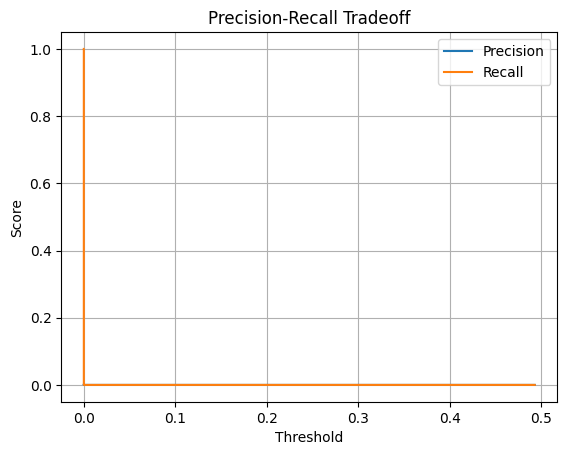

In [19]:
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")
plt.legend()
plt.grid(True)
plt.show()


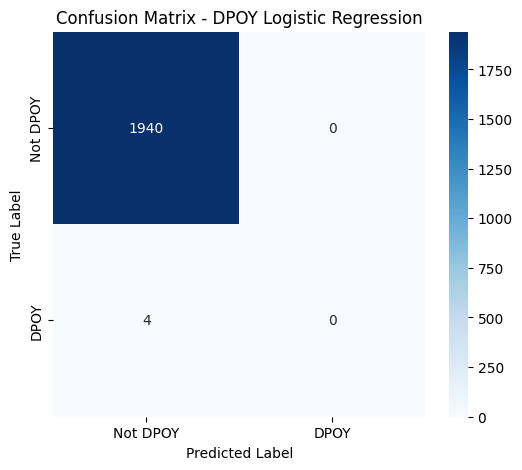

In [20]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred_custom)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not DPOY", "DPOY"],
            yticklabels=["Not DPOY", "DPOY"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DPOY Logistic Regression")
plt.show()

Moving on to the next model: Random Forest (with balancing)

In [21]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)


In [22]:
scaler_rf = StandardScaler()
X_train_scaled_rf = scaler_rf.fit_transform(X_train)
X_test_scaled_rf = scaler_rf.transform(X_test)

In [23]:
rf.fit(X_train_scaled_rf, y_train)
y_pred_rf = rf.predict(X_test_scaled_rf)

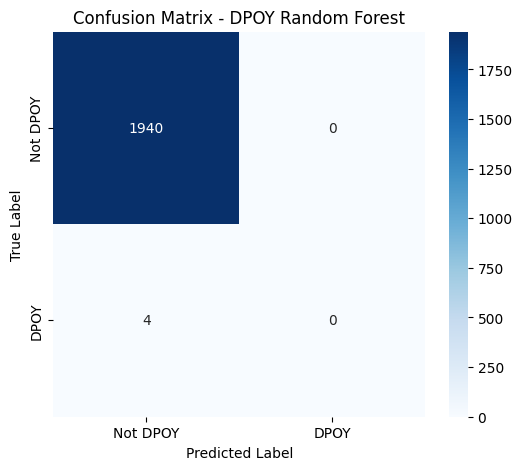

In [24]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not DPOY", "DPOY"],
            yticklabels=["Not DPOY", "DPOY"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DPOY Random Forest")
plt.show()

Moving on to XGBoost and scaling for class imbalance

In [25]:
# scale_pos_weight = (negatives / positives)
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(scale_pos_weight=scale, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\xgboost\training.py:183: UserWarning: [13:36:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


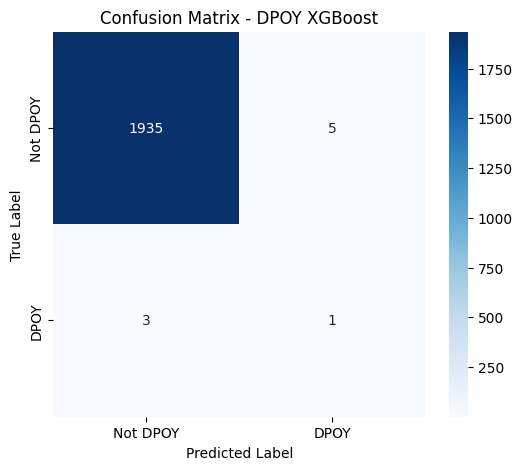

In [26]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not DPOY", "DPOY"],
            yticklabels=["Not DPOY", "DPOY"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DPOY XGBoost")
plt.show()

Moving on to Deep Learning models for comparison

In [27]:
# Setting train, test, splits for deep learning approach
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_nn)
X_test_nn = scaler_nn.transform(X_test_nn)

In [29]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_nn.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_nn.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [30]:
class DPOYNET(nn.Module):
    """
    A feedforward neural network for predicting NBA DPOY likelihood based on player stats.

    Args:
        input_dim (int): Number of input features
    """
    def __init__(self, input_dim):
        """
        Initializes the DPOYNet model with a series of fully connected layers,
        LeakyReLu activations, and dropout regularization.

        Args:
            input_dim (int): Number of input features
        """
        super(DPOYNET, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), # The expanding architecture
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            
            nn.Linear(16, 1),
            
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the network

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)
            
        Returns:
            torch.Tensor: Output tensor with shape (batch_size, 1), representing MVP prediction scores.
        """
        
        return self.network(x)
        

In [33]:
# Calculate class counts (assuming y_train is a pandas Series or NumPy array)
neg = (y_train_nn == 0).sum()
pos = (y_train_nn == 1).sum()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute pos_weight = (# of negative samples / # of positive samples)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

In [34]:
# Model training


model_nn = DPOYNET(input_dim=X_train_nn.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

num_epochs = 200
model_nn.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_nn(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}")

Epoch 1/200, Loss: 1442.6001
Epoch 2/200, Loss: 157.3565
Epoch 3/200, Loss: 101.0959
Epoch 4/200, Loss: 156.9541
Epoch 5/200, Loss: 64.1510
Epoch 6/200, Loss: 111.3679
Epoch 7/200, Loss: 69.5108
Epoch 8/200, Loss: 68.1266
Epoch 9/200, Loss: 45.2614
Epoch 10/200, Loss: 69.8154
Epoch 11/200, Loss: 63.9544
Epoch 12/200, Loss: 40.5049
Epoch 13/200, Loss: 69.1283
Epoch 14/200, Loss: 39.3419
Epoch 15/200, Loss: 35.0167
Epoch 16/200, Loss: 49.5341
Epoch 17/200, Loss: 45.0649
Epoch 18/200, Loss: 38.3292
Epoch 19/200, Loss: 60.2740
Epoch 20/200, Loss: 42.2997
Epoch 21/200, Loss: 39.5646
Epoch 22/200, Loss: 36.6683
Epoch 23/200, Loss: 38.2654
Epoch 24/200, Loss: 28.2504
Epoch 25/200, Loss: 22.5374
Epoch 26/200, Loss: 28.8491
Epoch 27/200, Loss: 23.6460
Epoch 28/200, Loss: 50.5060
Epoch 29/200, Loss: 25.7398
Epoch 30/200, Loss: 33.0370
Epoch 31/200, Loss: 24.1743
Epoch 32/200, Loss: 27.7762
Epoch 33/200, Loss: 55.0684
Epoch 34/200, Loss: 32.6586
Epoch 35/200, Loss: 29.0755
Epoch 36/200, Loss: 22.

Using the sigmoid function to convert 7.0 logit threshold to probability for the model to reference

In [35]:
model_nn.eval()
prob_threshold = 1 / (1 + np.exp(-7.0))

with torch.no_grad():
    y_pred_probs_nn = model_nn(X_test_tensor.to(device)).cpu().numpy()
    y_pred_nn = (y_pred_probs_nn > prob_threshold).astype(int)

print(confusion_matrix(y_test_nn, y_pred_nn))
print(classification_report(y_test_nn, y_pred_nn))

[[1845   95]
 [   0    4]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1940
           1       0.04      1.00      0.08         4

    accuracy                           0.95      1944
   macro avg       0.52      0.98      0.53      1944
weighted avg       1.00      0.95      0.97      1944



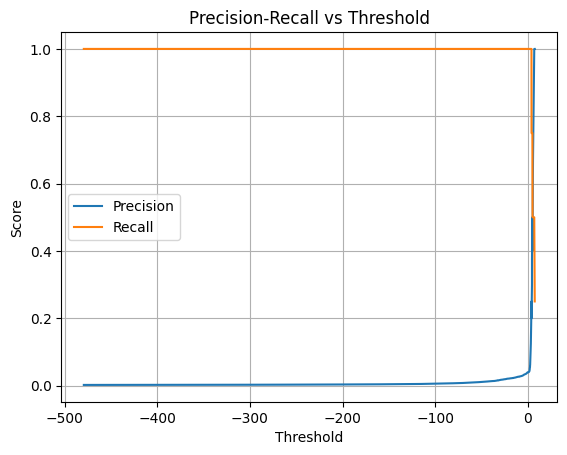

In [36]:
precision_nn, recall_nn, thresholds_nn = precision_recall_curve(y_test, y_pred_probs_nn)

plt.plot(thresholds_nn, precision_nn[:-1], label='Precision')
plt.plot(thresholds_nn, recall_nn[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
def predict_dpoy_candidates(
    model: torch.nn.Module,
    data: pd.DataFrame,
    feature_columns: list[str],
    player_id_column: str,
    threshold: float,
    scaler: object,
    device: torch.device = torch.device("cpu"),
    return_probs: bool = True
) -> pd.DataFrame:
    """
    Use a trained PyTorch model to predict DPOY candidates from unlabeled data.

    Args:
        model (torch.nn.Module): Trained PyTorch model (no final sigmoid).
        data (pd.DataFrame): Input DataFrame with player-season stats.
        feature_columns (list[str]): List of columns used as features.
        player_id_column (str): Column name for identifying players.
        threshold (float): Logit threshold to label a player as DPOY candidate.
        scaler (object): Scaler used during model training.
        device (torch.device): CPU or GPU. Defaults to CPU.
        return_probs (bool): If True, include predicted logit and probability columns.

    Returns:
        pd.DataFrame: Subset of input data predicted as DPOY candidates, with optional confidence scores.
    """
    model.eval()
    
    # Preprocess input features
    X = scaler.transform(data[feature_columns])
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    
    # Get logits from model
    with torch.no_grad():
        logits = model(X_tensor).cpu().numpy().flatten()
    
    # Apply threshold to get binary predictions
    predictions = (logits > threshold).astype(int)
    
    # Append predictions and optional scores
    data = data.copy()
    data["predicted_dpoy"] = predictions

    if return_probs:
        data["logit"] = logits
        data["probability"] = 1 / (1 + np.exp(-logits))  # manually apply sigmoid
    
    # Filter to DPOY candidates
    dpoy_candidates = data[data["predicted_dpoy"] == 1].sort_values(by="logit", ascending=False)

    return dpoy_candidates

In [43]:
# Loading a cleaned dataset that is not scaled
all_season_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")



In [44]:
feature_list = [
    "DWS", "BLK", "TRB", "FTA",
    "GS", "2P", "PF", "MP",
    "STL", "TOV"
]

Using the 2023 DPOY as a test target. The actual winner of the DPOY award for 2023 was Jaren Jackson Jr..

In [45]:
dpoy_candidates = predict_dpoy_candidates(
    model=model_nn,
    data=all_season_df,
    feature_columns=feature_list,
    player_id_column="Player",  
    threshold=7.0,
    scaler=scaler_nn,
    device=device
)

print(dpoy_candidates[["Player", "Team", "logit", "probability"]].head(10))


            Player Team     logit  probability
590  Dwight Howard  ORL  7.431787     0.999408


C:\Users\bartl\AppData\Local\Temp\ipykernel_34168\2560759751.py:46: RuntimeWarning: overflow encountered in exp
  data["probability"] = 1 / (1 + np.exp(-logits))  # manually apply sigmoid


These results are acceptable and the model can be saved for use in deployment.

In [46]:
# Deep Learning Model Save
model_path = os.path.join(versioned_dl_path, "dpoy_model_weights.pth")
torch.save(model_nn.state_dict(), model_path)

# Deep Learning Scaler save
scaler_path = os.path.join(versioned_dl_path, "dpoy_scaler.pkl")
joblib.dump(scaler_nn, scaler_path)

# Features and metadata save
feature_list_path = os.path.join(versioned_dl_path, "dpoy_feature_list.json")
metadata = {
    "timestamp": timestamp,
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 7.0,
    "notes" : "Deep learning DPOY model trained on all-season data"
}

# Feature list save

with open(feature_list_path, "w") as f:
    json.dump(metadata, f, indent=4)


In [47]:
# Machine Learning Model save
ml_model_path = os.path.join(versioned_ml_path, "dpoy_ml_model.pkl")
joblib.dump(model, ml_model_path)

# Machine Learning Scaler save
ml_scaler_path = os.path.join(versioned_ml_path, "dpoy__ml_scaler.pkl")
joblib.dump(scaler, ml_scaler_path)

# Metadata save

ml_metadata = {
    "timestamp": timestamp,
    "model_type" : str(type(model)).split("'")[1],
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 0.5,
    "notes" : "Best ML Model for DPOY prediction"
}

ml_metadata_path = os.path.join(versioned_ml_path, "dpoy_ml_feature_list.json")
with open(ml_metadata_path, "w") as f:
    json.dump(ml_metadata, f, indent=4)
